In [24]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from utils.evaluation import evaluate_pipeline
from utils import column_type_split

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
columns = column_type_split(X)

In [6]:
pipe_lr = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                    ("scaler", StandardScaler(), columns.numeric),
                ],
                remainder="passthrough",
            ),
        ),
        ("logistic", LogisticRegression(max_iter=200)),
    ]
)

In [7]:
pipe_xgb = Pipeline(
        [
            (
                "preprocess",
                ColumnTransformer(
                    [
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                dtype=np.int64,
                            ),
                            columns.categorical,
                        )
                    ],
                    remainder="passthrough",
                ),
            ),
            ("xgb", XGBClassifier()),
        ]
    )

In [8]:
pipe_mlp = Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                    ("scaler", StandardScaler(), columns.numeric),
                ],
                remainder="passthrough",
            ),
        ),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.001,
                batch_size="auto",
                learning_rate="adaptive",
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42,
            ),
        ),
    ]
)

In [ ]:
estimators_list: list[tuple[str, BaseEstimator]] = [
    ('logreg', pipe_lr),
    ('xgb', pipe_xgb),
    ('mlp', pipe_mlp),
]

In [14]:
voting_pipe = Pipeline(
    [("voting", VotingClassifier(estimators=estimators_list, voting="soft", n_jobs=-1))]
)

Модель VotingClassifier
F1-macro: 0.808 ± 0.005
F1-weighted: 0.859 ± 0.003


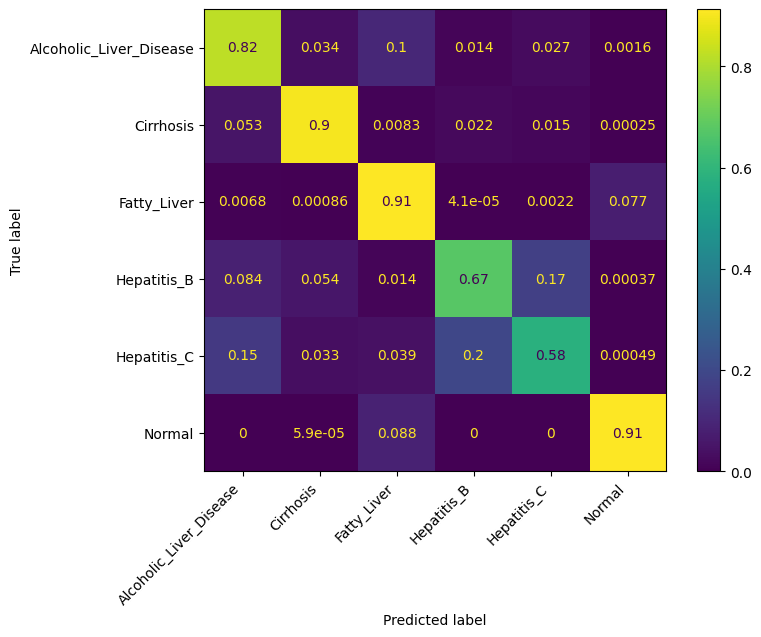

In [15]:
evaluate_pipeline(voting_pipe, X, y)

Голосование усредняет точность, поэтому модель становится потенциально стабильнее, но точность голосования оказывается хуже чем точность отдельного XGBoost

In [20]:
stacking_pipe = Pipeline(
    [
        (
            "stacking",
            StackingClassifier(
                estimators=estimators_list,
                final_estimator=LogisticRegression(),
                cv=5,
                n_jobs=-1,
            ),
        )
    ]
)

Модель StackingClassifier
F1-macro: 0.835 ± 0.006
F1-weighted: 0.878 ± 0.003


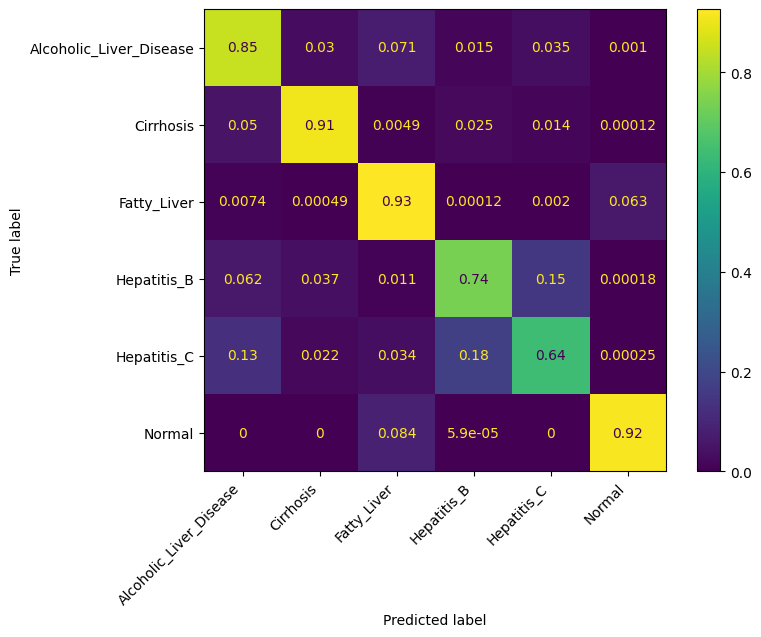

In [21]:
evaluate_pipeline(stacking_pipe, X, y)

Stacking обучает мета модель на ошибках всех базовых моделей. Ансамбль становится стабильнее из-за того, что для каждого класса выбирается наиболее точно предсказывающая его модель. Лучше всего работает когда между базовыми моделями есть заметное смещение точности на разные классы

In [23]:
meta_model = stacking_pipe[-1].final_estimator_
assert isinstance(meta_model, LogisticRegression)
class_names = y.unique()
base_names = [estimator[0] for estimator in estimators_list]

coefs = meta_model.coef_
n_classes = coefs.shape[0]
n_models = len(base_names)

coefs_reshaped = coefs.reshape(n_classes, n_models, n_classes)

model_importance = np.abs(coefs_reshaped).mean(axis=(0, 2))

importance_df = pd.DataFrame({
    'model': base_names,
    'avg_weight': model_importance
}).sort_values('avg_weight', ascending=False)

print("Итоговая важность базовых моделей:")
print(importance_df)

Итоговая важность базовых моделей:
    model  avg_weight
1     xgb    1.459530
0  logreg    0.737044
2     mlp    0.661218


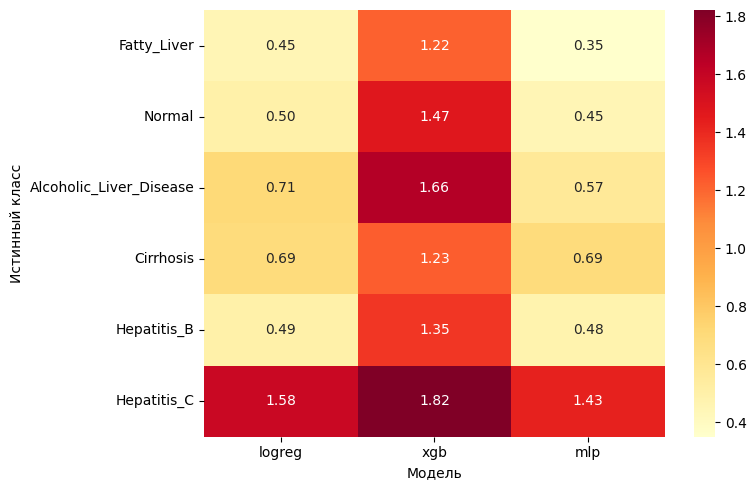

In [25]:
class_model_weights = np.abs(coefs_reshaped).mean(axis=2)

heatmap_df = pd.DataFrame(
    class_model_weights,
    index=y.unique(),
    columns=base_names
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd')
plt.ylabel('Истинный класс')
plt.xlabel('Модель')
plt.tight_layout()
plt.show()

Наибольшие веса у XGBoost, именно эта модель будет предсказывать большую часть объектов. Logreg и MLP будут лишь немного корректировать предсказания в граничных случаях